In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
# total number of color bins to use for visualization
vis_bins = 20

nice_text = {'C':'Cell Measured with Bins Starting at the Center of the Cell',
             'CCN':'Cell Measured with Bins Starting at the Center of the Nucleus',
             'CEN':'Cell Measured with Bins Starting at the Edge of the Nucleus'}

# ordered to match other figures
custom_order = ['Control','BP','SZ','SZA','MDD']

In [3]:
df = pd.read_csv('/Users/eweisbar/Downloads/aggregated_profiles_fibroblast.csv')

# filter to only mito_tubeness features
df = df[[x for x in df.columns if 'Cells_RadialDistribution_MeanFrac_mito_tubeness' in x] + ['label']]
df = df.groupby('label').median().reset_index()
df = df.set_index('label').reindex(custom_order)
df

,Cells_RadialDistribution_MeanFrac_mito_tubeness_C_6of16,Cells_RadialDistribution_MeanFrac_mito_tubeness_CEN_11of16,Cells_RadialDistribution_MeanFrac_mito_tubeness_CCN_1of12,Cells_RadialDistribution_MeanFrac_mito_tubeness_CCN_8of16,Cells_RadialDistribution_MeanFrac_mito_tubeness_CEN_4of16,Cells_RadialDistribution_MeanFrac_mito_tubeness_C_12of12,Cells_RadialDistribution_MeanFrac_mito_tubeness_CEN_4of12,Cells_RadialDistribution_MeanFrac_mito_tubeness_CEN_12of12,Cells_RadialDistribution_MeanFrac_mito_tubeness_C_3of12,Cells_RadialDistribution_MeanFrac_mito_tubeness_CCN_12of16,...,Cells_RadialDistribution_MeanFrac_mito_tubeness_CCN_2of12,Cells_RadialDistribution_MeanFrac_mito_tubeness_CCN_14of16,Cells_RadialDistribution_MeanFrac_mito_tubeness_CCN_7of12,Cells_RadialDistribution_MeanFrac_mito_tubeness_CCN_7of16,Cells_RadialDistribution_MeanFrac_mito_tubeness_CEN_8of12,Cells_RadialDistribution_MeanFrac_mito_tubeness_CCN_13of16,Cells_RadialDistribution_MeanFrac_mito_tubeness_CEN_12of16,Cells_RadialDistribution_MeanFrac_mito_tubeness_CCN_4of12,Cells_RadialDistribution_MeanFrac_mito_tubeness_CCN_3of16,Cells_RadialDistribution_MeanFrac_mito_tubeness_CEN_8of16
label,,,,,,,,,,,,,,,,,,,,,
Control,0.002245,-0.050574,0.019687,-0.027075,0.006051,0.069921,0.054788,-0.017880,-0.013805,-0.096181,...,0.002352,0.042988,-0.046486,-0.061962,-0.020723,-0.058717,0.014558,-0.003681,0.020054,-0.040219
BP,-0.000857,0.019285,-0.020503,0.020751,0.001947,-0.024789,0.063803,-0.233218,-0.006213,0.019995,...,-0.033057,0.022512,0.022198,-0.000189,0.062537,0.000478,0.021282,-0.034636,-0.049796,0.017668
SZ,0.002821,0.008203,-0.065699,0.049878,0.000563,0.020768,0.053801,-0.294424,-0.004743,0.032927,...,-0.105437,-0.019315,0.055925,0.031402,0.034747,0.013690,-0.011195,-0.077907,-0.086781,0.035978
SZA,-0.047190,0.034139,0.025214,0.068808,-0.054461,0.075497,0.006099,-0.220547,-0.046981,0.018831,...,0.024336,-0.010881,-0.017355,0.104690,0.029533,0.034359,0.049771,0.065979,0.103359,0.028395
MDD,-0.035329,-0.127724,0.128433,-0.046966,0.062702,0.130451,0.051647,0.092652,0.002344,-0.180303,...,0.209987,-0.085070,-0.017326,0.018959,-0.121249,-0.125484,-0.040668,0.179000,0.188673,-0.087393


In [21]:
# explore feature used for Mito Slope
dffilt = df[[x for x in df.columns if 'CEN' in x and '12' in x]]

#make a dataframe with the min and max values for each row
dfminmax = pd.DataFrame()
dfminmax['min'] = dffilt.min(axis=1)
dfminmax['max'] = dffilt.max(axis=1)
dfminmax['range'] = dfminmax['max'] - dfminmax['min']
dfminmax

,min,max,range
label,,,
Control,-0.037574,0.054788,0.092362
BP,-0.233218,0.079281,0.312499
SZ,-0.294424,0.088374,0.382798
SZA,-0.220547,0.095701,0.316248
MDD,-0.121249,0.102608,0.223857


# Functions

In [4]:
def rescale_df(df, vis_bins=False, castint=True):
    min_val = df.min().min()
    max_val = df.max().max()
    print(min_val, max_val)
    df = (df - min_val) / (max_val - min_val)
    min_val = df.min().min()
    max_val = df.max().max()
    print(min_val, max_val)
    if vis_bins:
        # scale from zero to vis_bins-1 for total bin number = vis_bins
        df = df*(vis_bins-1)
    if castint:
        df = df.astype(int)
    return df

# CEN, 12 bins - showing work

In [5]:
group = 'CEN'
nbins = 12

groupdf = df[[x for x in df.columns if f'of{nbins}' in x and f'_{group}_' in x]]
groupdf.columns = [x.replace(f'Cells_RadialDistribution_MeanFrac_mito_tubeness_{group}_','').replace(f'of{nbins}','') for x in groupdf.columns]

# min-max rescale data, scale to number of visualization bins to work with visualization strategy
groupdf = rescale_df(groupdf, vis_bins=vis_bins, castint=True)
groupdf.reset_index(inplace=True)
groupdf

-0.2944242285871057 0.1026078292425091
0.0 1.0


,label,4,12,1,10,3,5,9,7,6,11,2,8
0,Control,16,13,14,14,16,16,14,12,15,14,13,13
1,BP,17,2,12,11,16,17,14,17,17,11,13,17
2,SZ,16,0,14,11,15,16,13,18,17,11,13,15
3,SZA,14,3,14,12,13,14,16,18,17,11,10,15
4,MDD,16,18,18,9,18,14,10,10,13,16,19,8


In [6]:
data_dict = {}
for label in groupdf['label']:
    data_dict[label] = [groupdf.loc[groupdf['label']==label,str(x)].item() for x in range(1,nbins+1)]
data_dict

{'Control': [14, 13, 16, 16, 16, 15, 12, 13, 14, 14, 14, 13],
 'BP': [12, 13, 16, 17, 17, 17, 17, 17, 14, 11, 11, 2],
 'SZ': [14, 13, 15, 16, 16, 17, 18, 15, 13, 11, 11, 0],
 'SZA': [14, 10, 13, 14, 14, 17, 18, 15, 16, 12, 11, 3],
 'MDD': [18, 19, 18, 16, 14, 13, 10, 8, 10, 9, 16, 18]}

In [7]:
# SET UP DATA FOR POLAR PLOTTING
# Create angles from 0 to 2*pi
theta = np.linspace(0, 2 * np.pi, 200).tolist()
ringintlist = []
ringlist = []
for bin in range(0, nbins):
    ringintlist += [bin]*len(theta)
    ringlist += [f'ring {bin}']*len(theta)
colorlist = sns.color_palette("YlOrBr", vis_bins)

palette_dict = {}
for label in data_dict.keys():
    palette ={}
    for bin in range(0, nbins):
        palette[f'ring {bin}'] = colorlist[data_dict[label][bin]]
    palette_dict[label] = palette

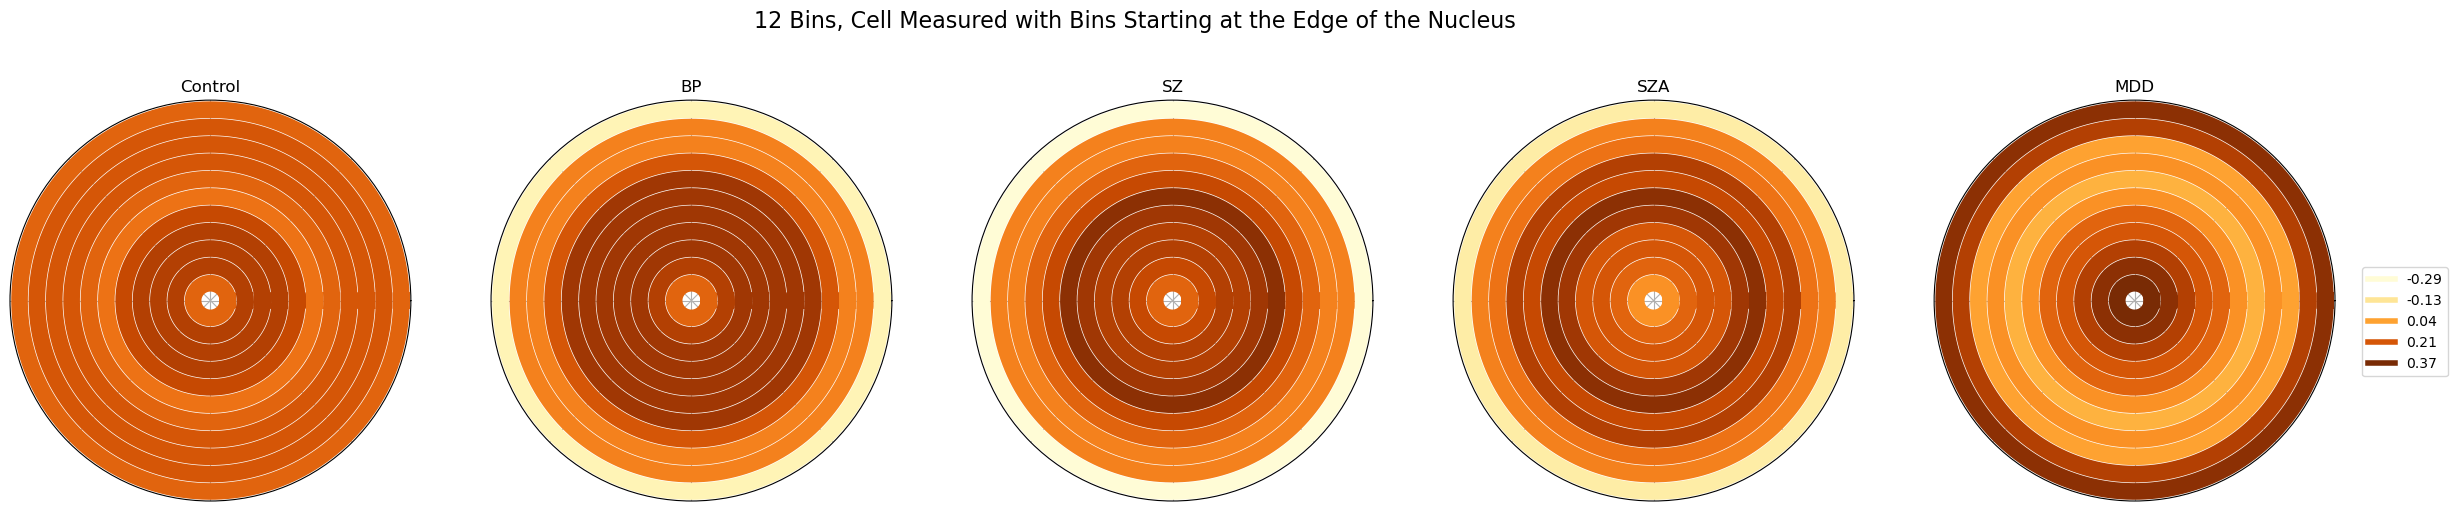

In [8]:
# make custom figure legend
min = df.min().min()
max = df.max().max()
mid = (max+min)/2
legend_elements = [Line2D([0], [0], color=colorlist[0], lw=4, label=f'{min:.2f}'),
                  Line2D([0], [0], color=colorlist[int(vis_bins/4)-1], lw=4, label=f'{(mid+min)/2:.2f}'),
                  Line2D([0], [0], color=colorlist[int(vis_bins/2)-1], lw=4, label=f'{mid:.2f}'),
                  Line2D([0], [0], color=colorlist[int(vis_bins*3/4)-1], lw=4, label=f'{(mid+max)/2:.2f}'),
                  Line2D([0], [0], color=colorlist[vis_bins-1], lw=4, label=f'{max:.2f}')]

# make subplots
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6*len(groupdf), 6),nrows=1, ncols=len(groupdf))

for i, label in enumerate(groupdf['label']):
    data = pd.DataFrame({'theta': theta*nbins, 'ringintlist': ringintlist,'ringlist': ringlist})
    g = sns.lineplot(data=data, x='theta', y='ringintlist', hue='ringlist', palette=palette_dict[label], ax=ax[i], linewidth=12)
    g.set(xlabel="")
    g.set(ylabel="")
    g.set(xticklabels=[])
    g.set(yticklabels=[])
    ax[i].set_title(label)
    ax[i].get_legend().remove()
fig.suptitle(f'{nbins} Bins, {nice_text[group]}', fontsize=16)
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, .6))
# plt.savefig(f'/Users/eweisbar/Documents/projects/MitoDonna/paper/polar_plot_{nbins}_{group}.png', bbox_inches='tight')


# All conditions

-0.2944242285871057 0.1026078292425091
0.0 1.0
-0.1703653626240174 0.3717670618640037
0.0 1.0
-0.2009889841514006 0.2336412619602886
0.0 1.0
-0.1803028918406388 0.277090805884961
0.0 1.0
-0.1169471296971877 0.1304507202754291
0.0 1.0
-0.138033105609106 0.1786107542857629
0.0 1.0


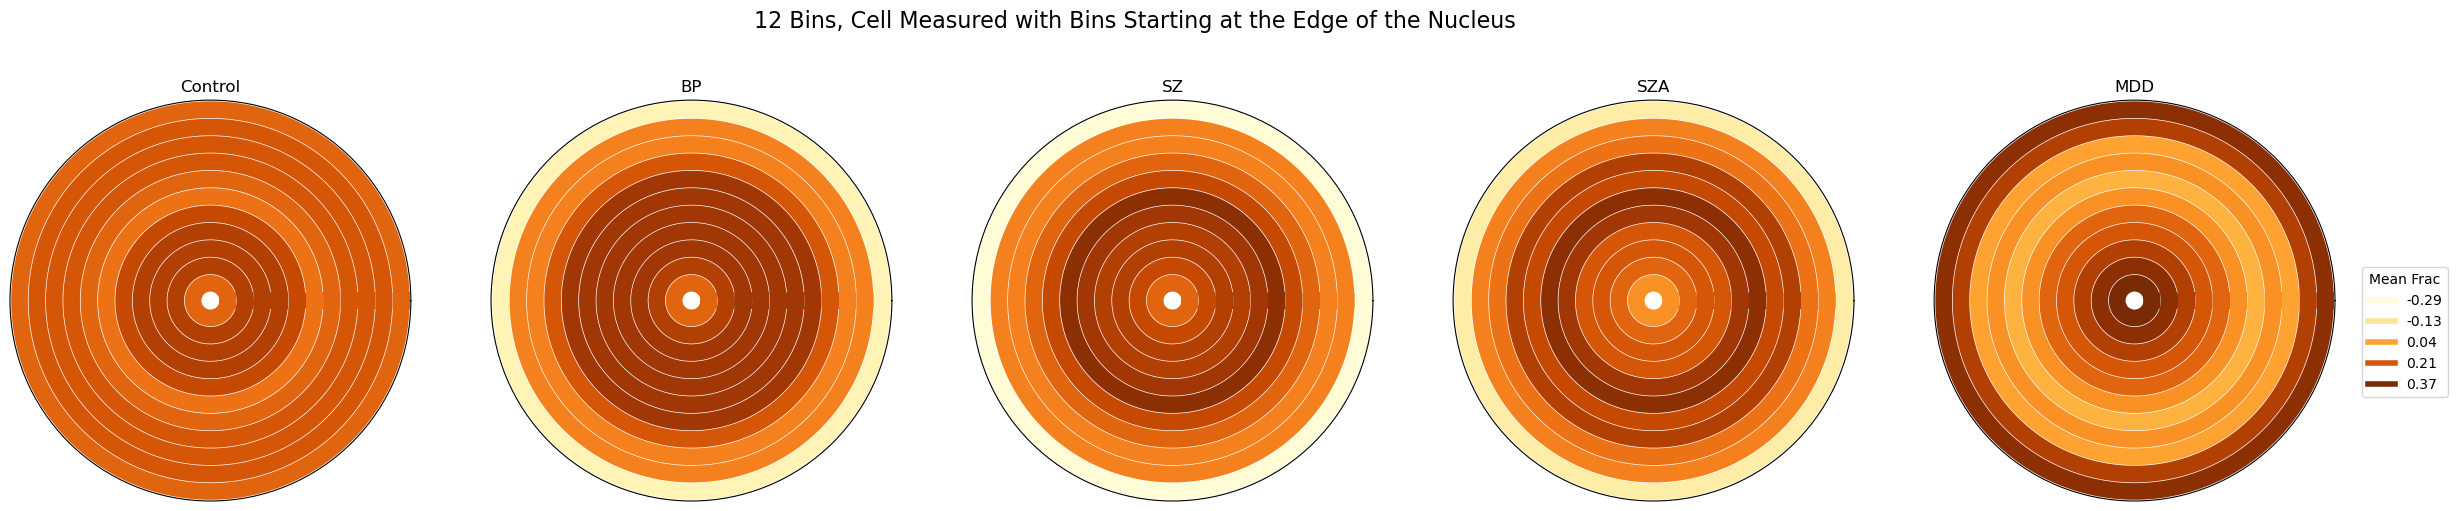

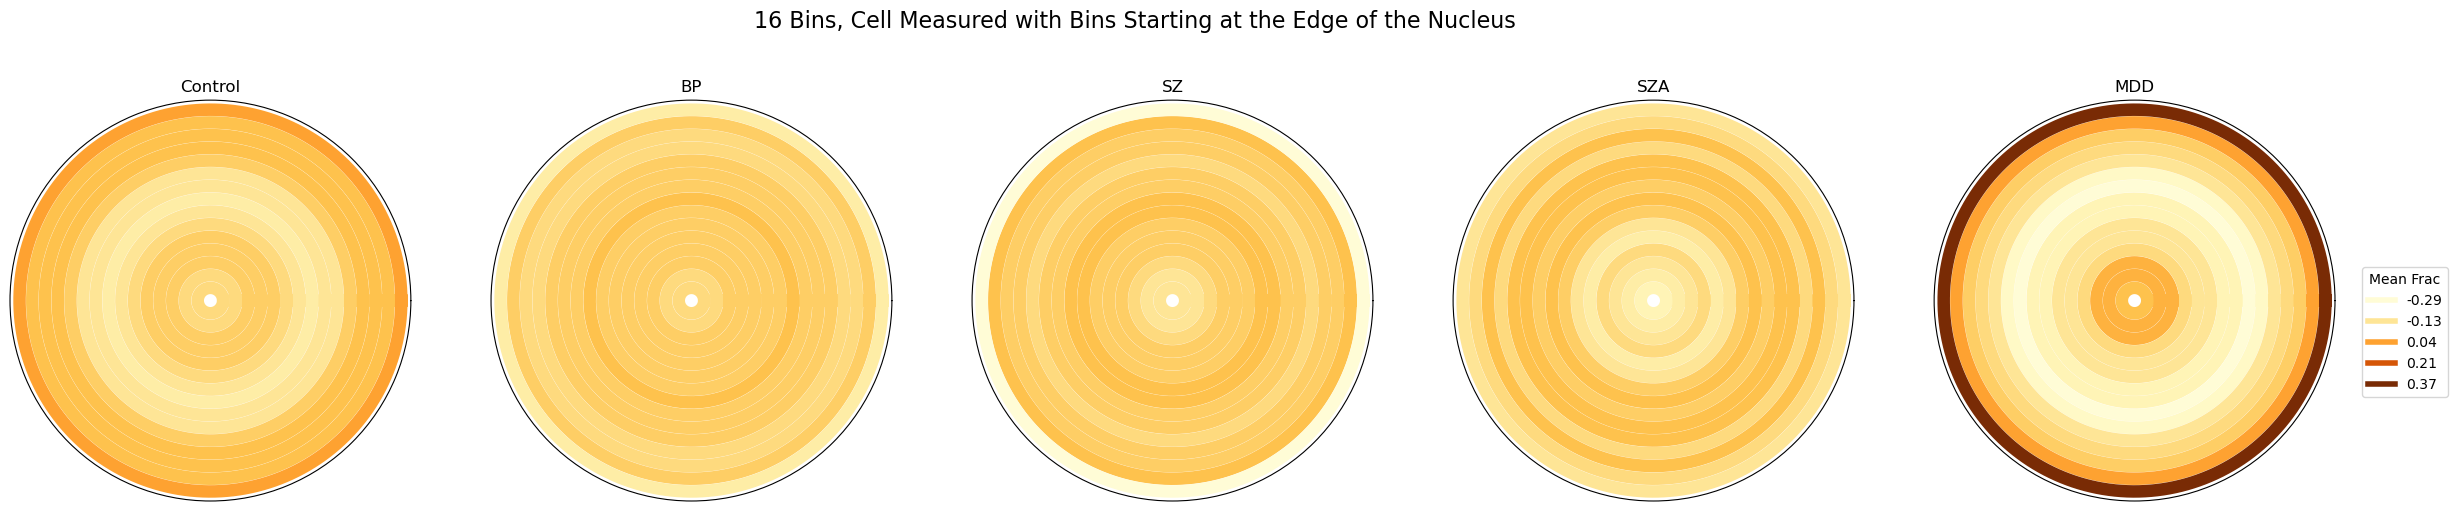

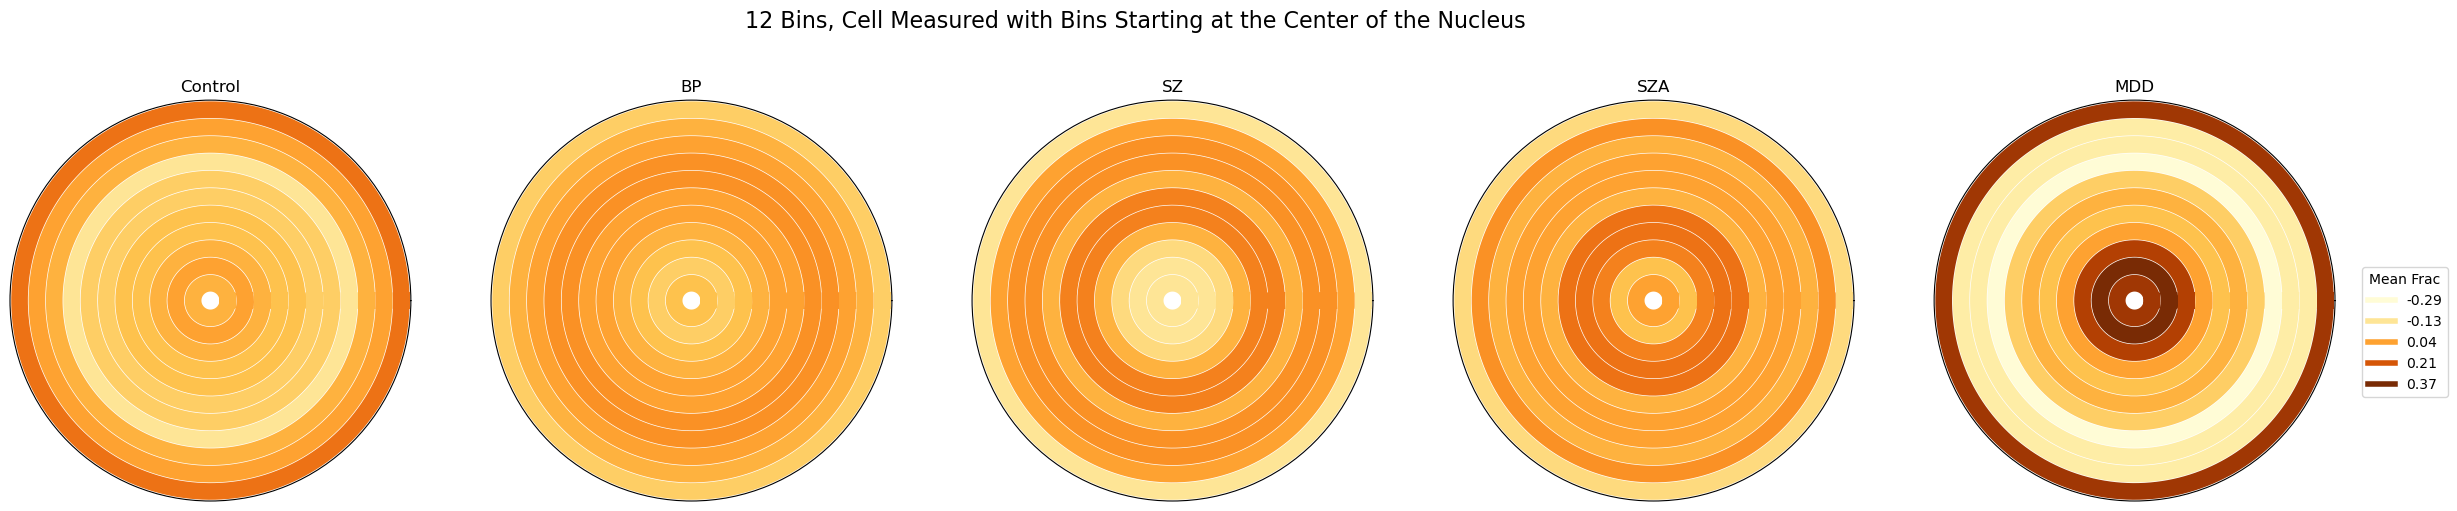

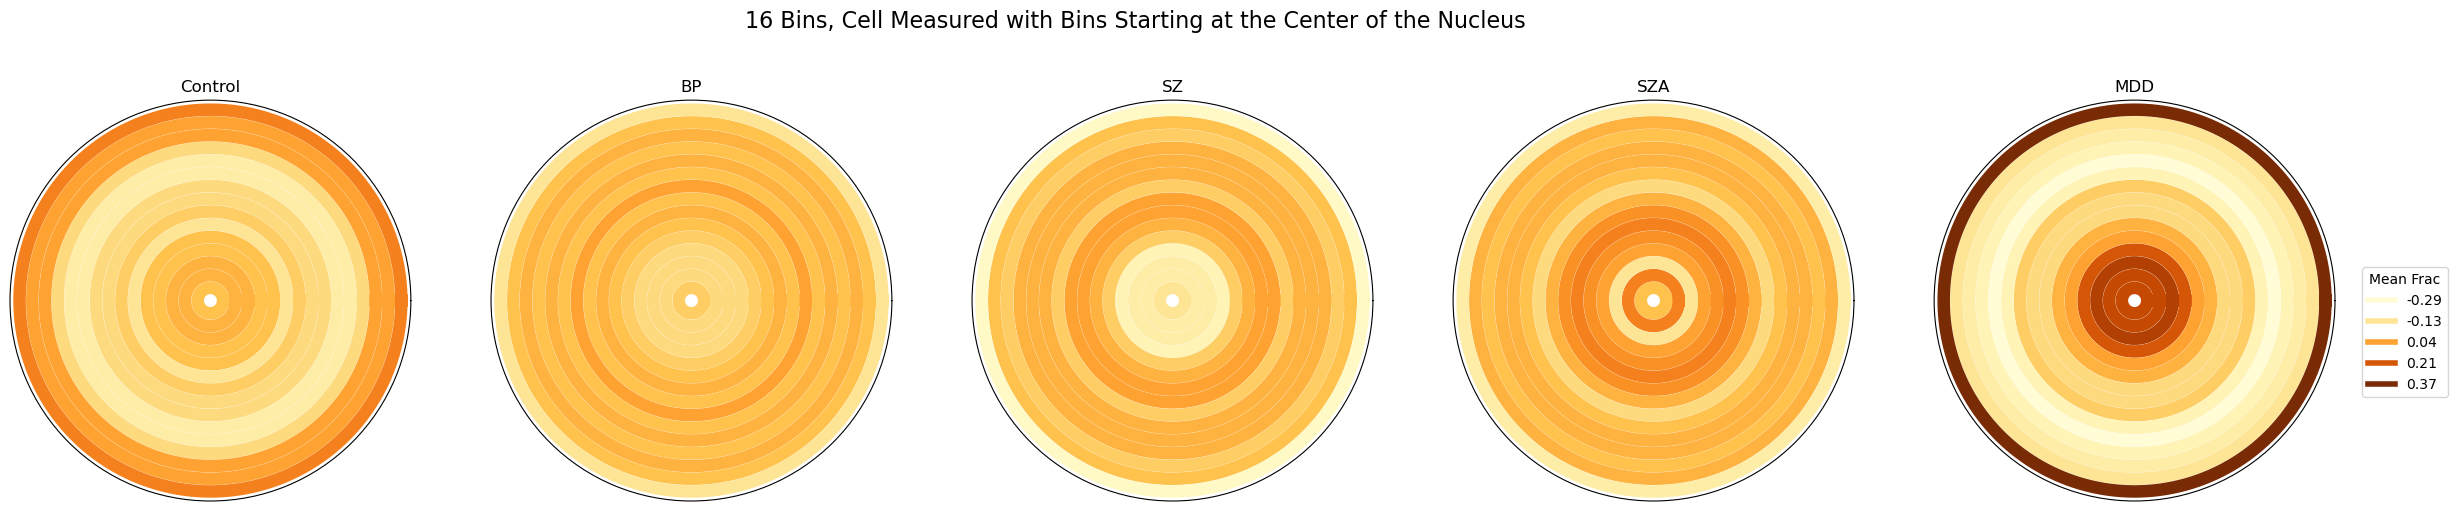

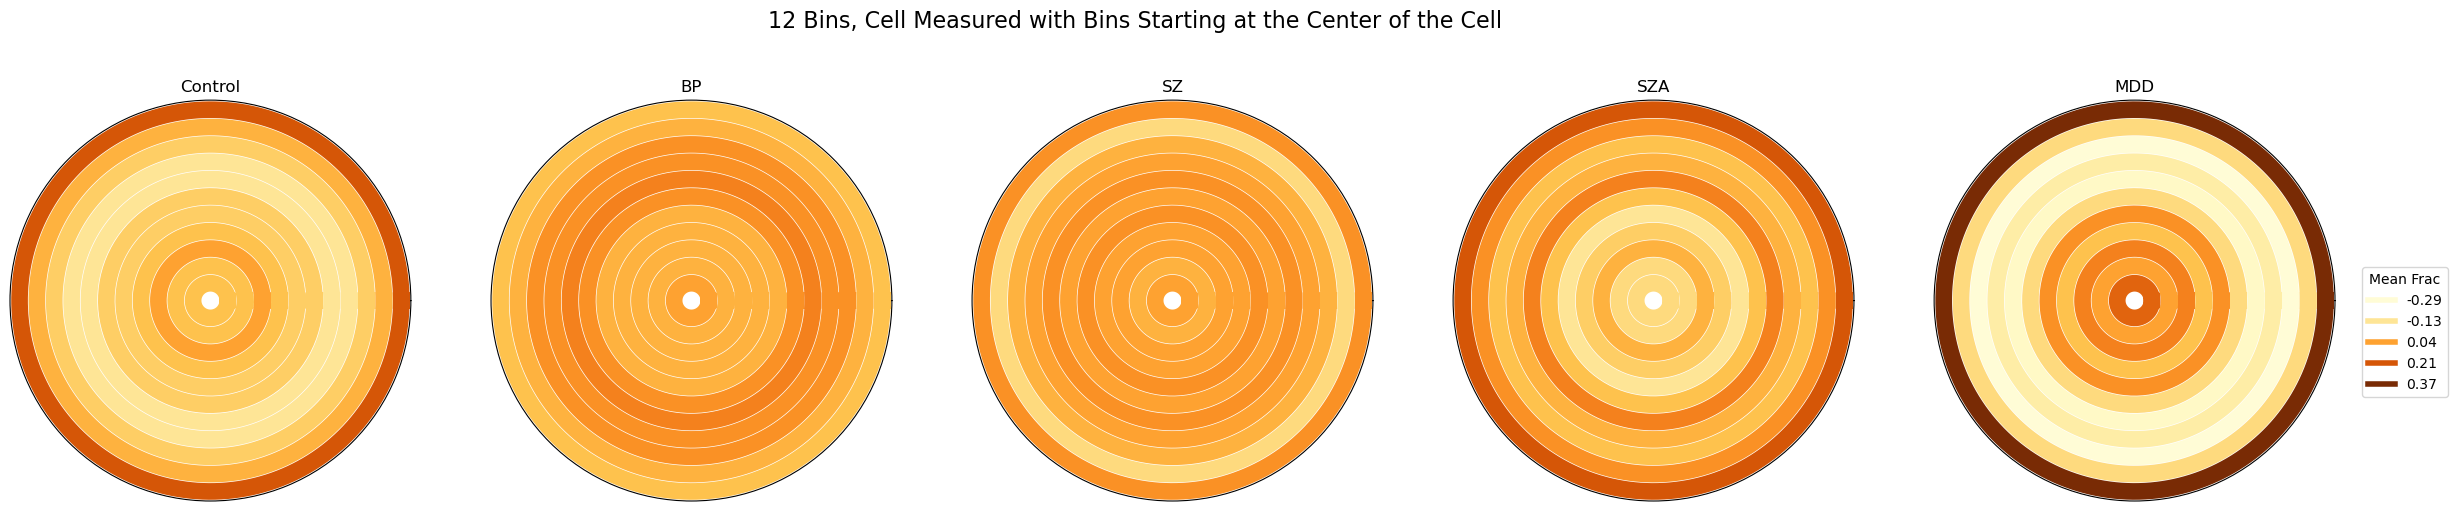

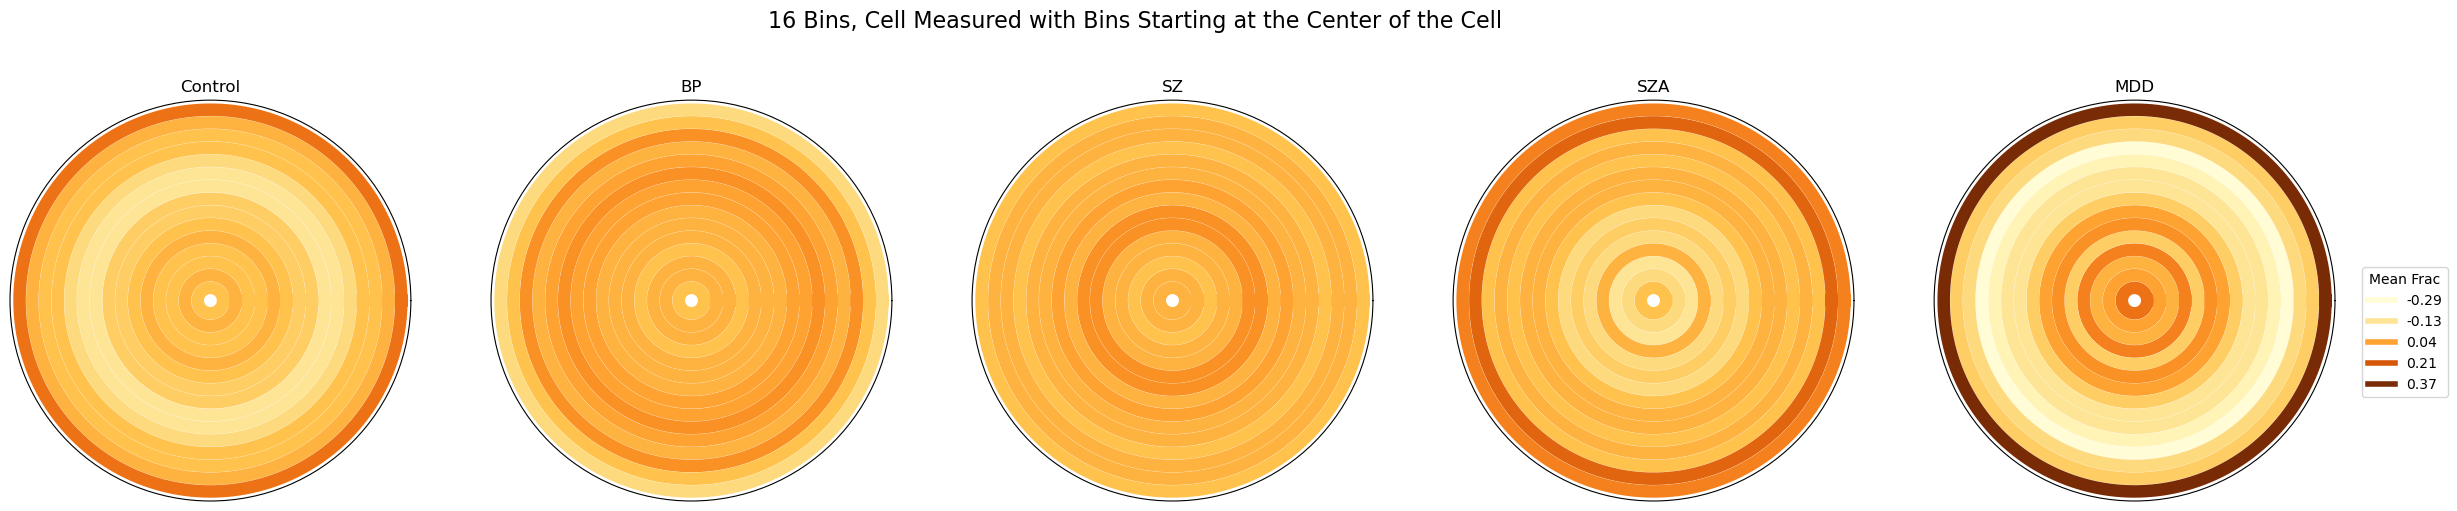

In [9]:
for group in ['CEN','CCN','C']:
    for nbins in [12,16]:
        groupdf = df[[x for x in df.columns if f'of{nbins}' in x and f'_{group}_' in x]]
        groupdf.columns = [x.replace(f'Cells_RadialDistribution_MeanFrac_mito_tubeness_{group}_','').replace(f'of{nbins}','') for x in groupdf.columns]

        # min-max rescale data, scale to number of visualization bins to work with visualization strategy
        groupdf = rescale_df(groupdf, vis_bins=vis_bins, castint=True)
        groupdf.reset_index(inplace=True)

        # Bin 1 is missing from CNN. Replace with zeros.
        if group =='CCN':
            groupdf['1'] = 0
        data_dict = {}
        for label in groupdf['label']:
            data_dict[label] = [groupdf.loc[groupdf['label']==label,str(x)].item() for x in range(1,nbins+1)]

        # SET UP DATA FOR POLAR PLOTTING
        # Create angles from 0 to 2*pi
        theta = np.linspace(0, 2 * np.pi, 200).tolist()
        ringintlist = []
        ringlist = []
        for bin in range(0, nbins):
            ringintlist += [bin]*len(theta)
            ringlist += [f'ring {bin}']*len(theta)
        colorlist = sns.color_palette("YlOrBr", vis_bins)

        palette_dict = {}
        for label in data_dict.keys():
            palette ={}
            for bin in range(0, nbins):
                palette[f'ring {bin}'] = colorlist[data_dict[label][bin]]
            palette_dict[label] = palette

        # make custom figure legend
        min = df.min().min()
        max = df.max().max()
        mid = (max+min)/2
        legend_elements = [Line2D([0], [0], color=colorlist[0], lw=4, label=f'{min:.2f}'),
                        Line2D([0], [0], color=colorlist[int(vis_bins/4)-1], lw=4, label=f'{(mid+min)/2:.2f}'),
                        Line2D([0], [0], color=colorlist[int(vis_bins/2)-1], lw=4, label=f'{mid:.2f}'),
                        Line2D([0], [0], color=colorlist[int(vis_bins*3/4)-1], lw=4, label=f'{(mid+max)/2:.2f}'),
                        Line2D([0], [0], color=colorlist[vis_bins-1], lw=4, label=f'{max:.2f}')]

        # make subplots
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6*len(groupdf), 6),nrows=1, ncols=len(groupdf))

        if nbins == 12:
            linewidth = 12
        elif nbins == 16:
            linewidth = 9
        for i, label in enumerate(groupdf['label']):
            data = pd.DataFrame({'theta': theta*nbins, 'ringintlist': ringintlist,'ringlist': ringlist})
            g = sns.lineplot(data=data, x='theta', y='ringintlist', hue='ringlist', palette=palette_dict[label], ax=ax[i], linewidth=linewidth)
            g.set(xlabel="",ylabel="",xticklabels=[],yticklabels=[])
            ax[i].set_title(label)
            ax[i].get_legend().remove()
            ax[i].grid(False)
        fig.suptitle(f'{nbins} Bins, {nice_text[group]}', fontsize=16)
        plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, .6),title='Mean Frac')
        plt.savefig(f'/Users/eweisbar/Desktop/github/2025_Haghighi_Mito/results/supplemental_fig_radial_dist/MeanFrac/polar_plot_{nbins}_{group}.png', bbox_inches='tight')